# Report Visualizations

Generates all figures for the ACL report from training summaries and submission CSVs.

**Required files in working directory:**
- `training_summary_v1.json`, `training_summary_v2.json`, `training_summary_v3.json`
- `submission_v7.csv`, `submission_v7_attn.csv`, `submission_v7_mlp.csv`, `submission_v8.csv`
- `test.csv`
- `train.csv` (for compression analysis)

In [1]:
import json
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.linewidth'] = 0.8

os.makedirs('figures', exist_ok=True)
print('Ready.')

Ready.


## 1. Load Training Summaries

In [2]:
# Load all available training summaries
summaries = {}
for f in sorted(os.listdir('.')):
    if f.startswith('training_summary') and f.endswith('.json'):
        with open(f) as fp:
            data = json.load(fp)
        summaries[f] = data
        print(f'\n=== {f} ===')
        for k, v in data.items():
            print(f'  {k}: {v}')

## 2. Score Progression Chart

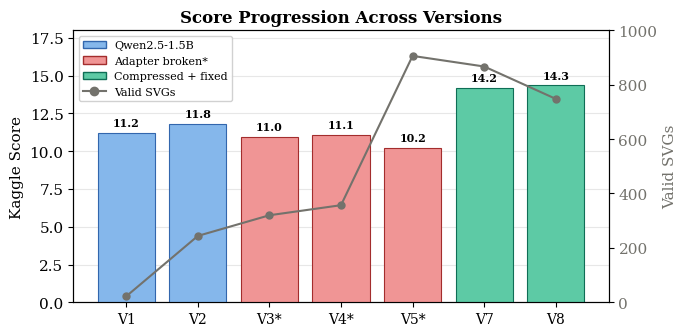

Saved: figures/score_progression.{png,pdf}


In [3]:
# Confirmed Kaggle scores
versions = ['V1', 'V2', 'V3*', 'V4*', 'V5*', 'V7', 'V8']
scores = [11.23, 11.83, 10.96, 11.07, 10.21, 14.20, 14.35]
valid_svgs = [22, 244, 320, 357, 906, 867, 748]
colors_bar = ['#85B7EB', '#85B7EB', '#F09595', '#F09595', '#F09595', '#5DCAA5', '#5DCAA5']
edge_colors = ['#3266ad', '#3266ad', '#A32D2D', '#A32D2D', '#A32D2D', '#0F6E56', '#0F6E56']

fig, ax1 = plt.subplots(figsize=(7, 3.5))

bars = ax1.bar(range(len(versions)), scores, color=colors_bar, edgecolor=edge_colors, linewidth=0.8, zorder=3)
ax1.set_ylabel('Kaggle Score', fontsize=11)
ax1.set_ylim(0, 18)
ax1.set_xticks(range(len(versions)))
ax1.set_xticklabels(versions, fontsize=10)
ax1.grid(axis='y', alpha=0.3, zorder=0)

# Add score labels on bars
for i, (v, s) in enumerate(zip(versions, scores)):
    ax1.text(i, s + 0.3, f'{s:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Valid SVGs on secondary axis
ax2 = ax1.twinx()
ax2.plot(range(len(versions)), valid_svgs, 'o-', color='#73726c', markersize=5, linewidth=1.5, zorder=4)
ax2.set_ylabel('Valid SVGs', fontsize=11, color='#73726c')
ax2.set_ylim(0, 1000)
ax2.tick_params(axis='y', labelcolor='#73726c')

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#85B7EB', edgecolor='#3266ad', label='Qwen2.5-1.5B'),
    Patch(facecolor='#F09595', edgecolor='#A32D2D', label='Adapter broken*'),
    Patch(facecolor='#5DCAA5', edgecolor='#0F6E56', label='Compressed + fixed'),
    Line2D([0], [0], color='#73726c', marker='o', label='Valid SVGs'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.9)

plt.title('Score Progression Across Versions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/score_progression.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/score_progression.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/score_progression.{png,pdf}')

## 3. SVG Compression Analysis

In [4]:
# Compress SVGs and show before/after distribution
FLOAT_RE = re.compile(r'-?\d+\.\d{3,}')

def compress_svg(svg_text):
    svg_text = FLOAT_RE.sub(
        lambda m: f'{float(m.group()):.1f}'.rstrip('0').rstrip('.'), svg_text
    )
    svg_text = re.sub(r'\s*filling="[^"]*"', '', svg_text)
    svg_text = re.sub(r'\s*fill-opacity="1\.0"', '', svg_text)
    svg_text = re.sub(r'\s*stroke-opacity="1\.0"', '', svg_text)
    svg_text = re.sub(r'\s+', ' ', svg_text).strip()
    return svg_text

# Load train.csv
df = pd.read_csv('train.csv')
original_lens = []
compressed_lens = []
filtered_lens = []

for _, row in df.iterrows():
    svg = str(row['svg']).strip()
    if not svg.startswith('<svg') or '</svg>' not in svg:
        continue
    orig_len = len(svg)
    original_lens.append(orig_len)
    compressed = compress_svg(svg)
    comp_len = len(compressed)
    if comp_len > 3000 or len(re.findall(r'<path[\s>]', compressed)) > 30:
        filtered_lens.append(comp_len)
    else:
        compressed_lens.append(comp_len)

print(f'Original: {len(original_lens)} SVGs, mean={np.mean(original_lens):.0f}')
print(f'Compressed (kept): {len(compressed_lens)}, mean={np.mean(compressed_lens):.0f}')
print(f'Filtered out: {len(filtered_lens)}')
print(f'Compression ratio: {100*(1 - np.sum(compressed_lens)/np.sum(original_lens)):.0f}%')

Original: 50000 SVGs, mean=2524
Compressed (kept): 49362, mean=1076
Filtered out: 638
Compression ratio: 58%


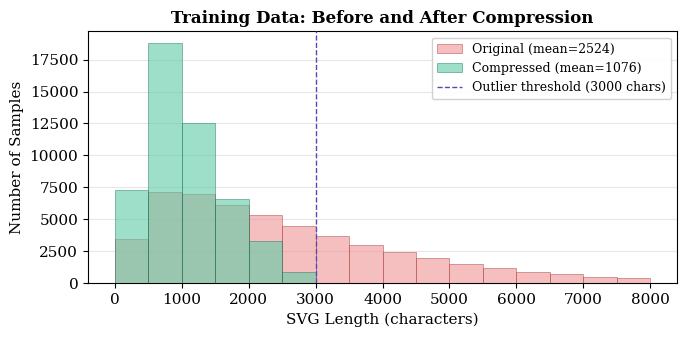

Saved: figures/compression_analysis.{png,pdf}


In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))

bins = np.arange(0, 8001, 500)
ax.hist(original_lens, bins=bins, alpha=0.6, color='#F09595', edgecolor='#A32D2D',
        linewidth=0.5, label=f'Original (mean={np.mean(original_lens):.0f})', zorder=3)
ax.hist(compressed_lens, bins=bins, alpha=0.6, color='#5DCAA5', edgecolor='#0F6E56',
        linewidth=0.5, label=f'Compressed (mean={np.mean(compressed_lens):.0f})', zorder=4)

# Mark the 3000 char cutoff
ax.axvline(x=3000, color='#534AB7', linestyle='--', linewidth=1, label='Outlier threshold (3000 chars)', zorder=5)

ax.set_xlabel('SVG Length (characters)', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_title('Training Data: Before and After Compression', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig('figures/compression_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/compression_analysis.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/compression_analysis.{png,pdf}')

## 4. Training Loss Curves

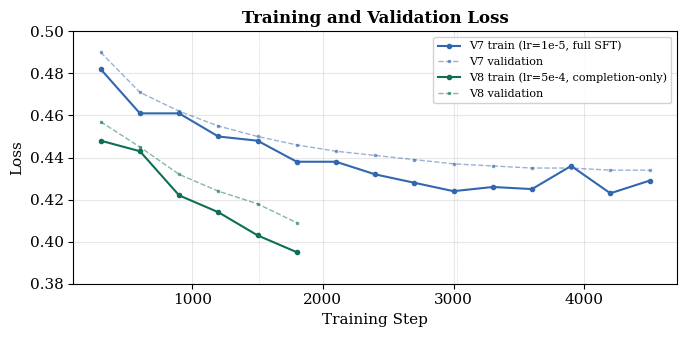

Saved: figures/loss_curves.{png,pdf}


In [6]:
# V7 loss data (from V7 notebook output)
v7_steps =  [300, 600, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000, 3300, 3600, 3900, 4200, 4500]
v7_train =  [0.482, 0.461, 0.461, 0.450, 0.448, 0.438, 0.438, 0.432, 0.428, 0.424, 0.426, 0.425, 0.436, 0.423, 0.429]
v7_val =    [0.490, 0.471, 0.462, 0.455, 0.450, 0.446, 0.443, 0.441, 0.439, 0.437, 0.436, 0.435, 0.435, 0.434, 0.434]

# V8 loss data (from V8 training output)
v8_steps =  [300, 600, 900, 1200, 1500, 1800]
v8_train =  [0.448, 0.443, 0.422, 0.414, 0.403, 0.395]
v8_val =    [0.457, 0.445, 0.432, 0.424, 0.418, 0.409]

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(v7_steps, v7_train, 'o-', color='#3266ad', markersize=3, linewidth=1.5, label='V7 train (lr=1e-5, full SFT)')
ax.plot(v7_steps, v7_val, 's--', color='#3266ad', markersize=2, linewidth=1, alpha=0.5, label='V7 validation')
ax.plot(v8_steps, v8_train, 'o-', color='#0F6E56', markersize=3, linewidth=1.5, label='V8 train (lr=5e-4, completion-only)')
ax.plot(v8_steps, v8_val, 's--', color='#0F6E56', markersize=2, linewidth=1, alpha=0.5, label='V8 validation')

# Mark epoch boundaries for V7 (48375/32 = 1512 steps/epoch)
for ep_step in [1512, 3024]:
    ax.axvline(x=ep_step, color='gray', linestyle=':', linewidth=0.5, alpha=0.5)

ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.9, loc='upper right')
ax.set_ylim(0.38, 0.50)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/loss_curves.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/loss_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/loss_curves.{png,pdf}')

## 5. LoRA Ablation Comparison

In [7]:
import xml.etree.ElementTree as ET
from collections import Counter

ALLOWED_TAGS = {
    'svg', 'g', 'path', 'rect', 'circle', 'ellipse', 'line', 'polyline',
    'polygon', 'defs', 'use', 'symbol', 'clipPath', 'mask',
    'linearGradient', 'radialGradient', 'stop', 'text', 'tspan',
    'title', 'desc', 'style', 'pattern', 'marker', 'filter'
}

COLOR_WORDS = ['red','blue','green','yellow','orange','purple','black','white','pink','brown','gray','grey']
HEX_MAP = {
    'red': ['ff0000','ff4444','f44336','e53935'],
    'blue': ['0000ff','1976d2','2196f3','3f51b5','0d47a1'],
    'green': ['00ff00','4caf50','228b22','2e7d32','388e3c'],
    'orange': ['ff9800','ff9d00','f57c00','ff6600'],
    'yellow': ['ffff00','ffc107','ffeb3b','fdd835'],
    'purple': ['800080','9c27b0','7b1fa2','f4c9ff','ce93d8'],
    'pink': ['ff69b4','e91e63','f06292','ec407a'],
    'black': ['000000','1a1a1a','212121','2c2c2c'],
    'white': ['ffffff','fafafa','f5f5f5'],
    'brown': ['795548','5d4037','8d6e63','3e2723'],
    'gray': ['808080','9e9e9e','757575','616161','bdbdbd'],
    'grey': ['808080','9e9e9e','757575','616161','bdbdbd'],
}

def analyze_submission(csv_path, test_csv_path):
    df = pd.read_csv(csv_path)
    test_df = pd.read_csv(test_csv_path)
    merged = pd.merge(test_df, df, on='id')
    
    stats = {'valid': 0, 'fallback': 0, 'lengths': [], 'path_counts': [],
             'color_match': 0, 'color_total': 0, 'viewboxes': Counter(),
             'tags': Counter(), 'unique_starts': set()}
    
    for _, row in merged.iterrows():
        svg = str(row['svg'])
        prompt = str(row['prompt'])
        if len(svg) < 190:
            stats['fallback'] += 1; continue
        stats['valid'] += 1
        stats['lengths'].append(len(svg))
        stats['unique_starts'].add(svg[:80])
        stats['path_counts'].append(len(re.findall(r'<path', svg)))
        vb = re.search(r'viewBox="([^"]+)"', svg)
        if vb: stats['viewboxes'][vb.group(1)] += 1
        for tag in re.findall(r'<(\w+)[\s>/]', svg):
            stats['tags'][tag] += 1
        # Color matching
        prompt_colors = [c for c in COLOR_WORDS if c in prompt.lower()]
        if prompt_colors:
            stats['color_total'] += 1
            svg_lower = svg.lower()
            found = any(c in svg_lower for c in prompt_colors)
            if not found:
                for c in prompt_colors:
                    for h in HEX_MAP.get(c, []):
                        if h in svg_lower: found = True; break
                    if found: break
            if found: stats['color_match'] += 1
    return stats

# Analyze all ablation submissions
ablation_files = {
    'Both (V7)': 'v7/submission_v7.csv',
    'Attention only': 'v7_ablations/submission_v7_attn.csv',
    'MLP only': 'v7_ablations/submission_v7_mlp.csv',
}

ablation_stats = {}
for label, f in ablation_files.items():
    if os.path.exists(f):
        ablation_stats[label] = analyze_submission(f, 'test.csv')
        s = ablation_stats[label]
        print(f'{label}: valid={s["valid"]}, fb={s["fallback"]}, '
              f'color={100*s["color_match"]/max(s["color_total"],1):.1f}%, '
              f'mean_len={np.mean(s["lengths"]):.0f}, '
              f'mean_paths={np.mean(s["path_counts"]):.1f}')
    else:
        print(f'{label}: FILE NOT FOUND ({f})')

Both (V7): valid=867, fb=133, color=59.5%, mean_len=648, mean_paths=2.2
Attention only: valid=692, fb=308, color=30.6%, mean_len=465, mean_paths=4.1
MLP only: valid=866, fb=134, color=59.8%, mean_len=635, mean_paths=2.2


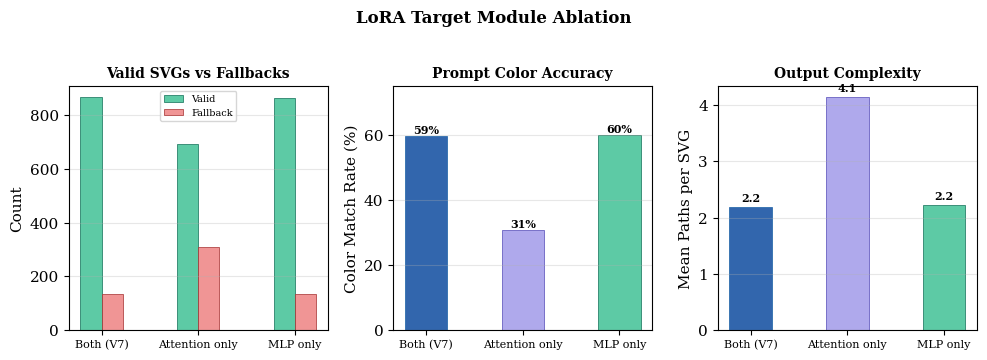

Saved: figures/ablation_comparison.{png,pdf}


In [8]:
# Ablation bar chart - key metrics side by side
labels = list(ablation_stats.keys())
x = np.arange(len(labels))
width = 0.22

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

# Panel 1: Valid SVGs and Fallbacks
ax = axes[0]
valids = [ablation_stats[l]['valid'] for l in labels]
fallbacks = [ablation_stats[l]['fallback'] for l in labels]
ax.bar(x - width/2, valids, width, color='#5DCAA5', edgecolor='#0F6E56', linewidth=0.5, label='Valid')
ax.bar(x + width/2, fallbacks, width, color='#F09595', edgecolor='#A32D2D', linewidth=0.5, label='Fallback')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Count')
ax.set_title('Valid SVGs vs Fallbacks', fontsize=10, fontweight='bold')
ax.legend(fontsize=7)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Color match rate
ax = axes[1]
color_rates = [100*ablation_stats[l]['color_match']/max(ablation_stats[l]['color_total'],1) for l in labels]
bars = ax.bar(x, color_rates, width*2, color=['#3266ad', '#AFA9EC', '#5DCAA5'],
              edgecolor=['#185FA5', '#534AB7', '#0F6E56'], linewidth=0.5)
for i, v in enumerate(color_rates):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Color Match Rate (%)')
ax.set_title('Prompt Color Accuracy', fontsize=10, fontweight='bold')
ax.set_ylim(0, 75)
ax.grid(axis='y', alpha=0.3)

# Panel 3: Mean paths per SVG
ax = axes[2]
mean_paths = [np.mean(ablation_stats[l]['path_counts']) for l in labels]
bars = ax.bar(x, mean_paths, width*2, color=['#3266ad', '#AFA9EC', '#5DCAA5'],
              edgecolor=['#185FA5', '#534AB7', '#0F6E56'], linewidth=0.5)
for i, v in enumerate(mean_paths):
    ax.text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Mean Paths per SVG')
ax.set_title('Output Complexity', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('LoRA Target Module Ablation', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/ablation_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/ablation_comparison.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/ablation_comparison.{png,pdf}')

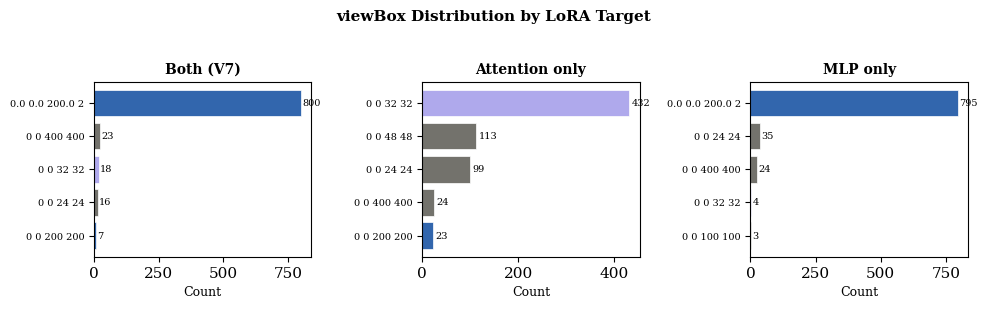

Saved: figures/ablation_viewbox.{png,pdf}


In [9]:
# ViewBox distribution per ablation variant
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i, (label, stats) in enumerate(ablation_stats.items()):
    ax = axes[i]
    top_vbs = stats['viewboxes'].most_common(5)
    vb_labels = [v[0][:15] for v in top_vbs]
    vb_counts = [v[1] for v in top_vbs]
    colors_vb = ['#3266ad' if '200' in vb_labels[j] else '#AFA9EC' if '32' in vb_labels[j] else '#73726c'
                 for j in range(len(vb_labels))]
    ax.barh(range(len(vb_labels)), vb_counts, color=colors_vb, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(vb_labels)))
    ax.set_yticklabels(vb_labels, fontsize=7)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Count', fontsize=9)
    ax.invert_yaxis()
    for j, c in enumerate(vb_counts):
        ax.text(c + 5, j, str(c), va='center', fontsize=7)

plt.suptitle('viewBox Distribution by LoRA Target', fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/ablation_viewbox.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/ablation_viewbox.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/ablation_viewbox.{png,pdf}')

## 6. Training Summary Comparison Table

In [10]:
# Build comparison table from all available training summaries
rows = []
known_scores = {
    'v1': 11.23, 'v2': 11.83,
    'v7': 14.20, 'v8': 14.35,
}

summary_data = [
    ('V1', 'Qwen2.5-Coder-1.5B', 32, 2e-4, 2, 48902, 0.290, 456.1, 'A100-40GB', 11.23),
    ('V2', 'Qwen2.5-Coder-1.5B', 32, 2e-4, 2, 48902, 0.309, 456.2, 'A100-40GB', 11.83),
    ('V7', 'Qwen3.5-2B', 32, 1e-5, 3, 48375, 0.444, 950.7, 'RTX PRO 6000', 14.20),
    ('V8', 'Qwen3.5-2B', 32, 5e-4, 2, 48375, None, None, 'RTX PRO 6000', 14.35),
]

print(f'{"Ver":<4} {"Model":<22} {"r":<4} {"LR":<8} {"Ep":<4} {"Samples":<8} {"Loss":<8} {"Time(m)":<10} {"GPU":<16} {"Score":<6}')
print('-' * 95)
for row in summary_data:
    ver, model, r, lr, ep, samples, loss, time_m, gpu, score = row
    loss_s = f'{loss:.3f}' if loss else 'N/A'
    time_s = f'{time_m:.0f}' if time_m else 'N/A'
    print(f'{ver:<4} {model:<22} {r:<4} {lr:<8.0e} {ep:<4} {samples:<8} {loss_s:<8} {time_s:<10} {gpu:<16} {score:<6.2f}')

Ver  Model                  r    LR       Ep   Samples  Loss     Time(m)    GPU              Score 
-----------------------------------------------------------------------------------------------
V1   Qwen2.5-Coder-1.5B     32   2e-04    2    48902    0.290    456        A100-40GB        11.23 
V2   Qwen2.5-Coder-1.5B     32   2e-04    2    48902    0.309    456        A100-40GB        11.83 
V7   Qwen3.5-2B             32   1e-05    3    48375    0.444    951        RTX PRO 6000     14.20 
V8   Qwen3.5-2B             32   5e-04    2    48375    N/A      N/A        RTX PRO 6000     14.35 


## 7. Output Length Distribution Comparison

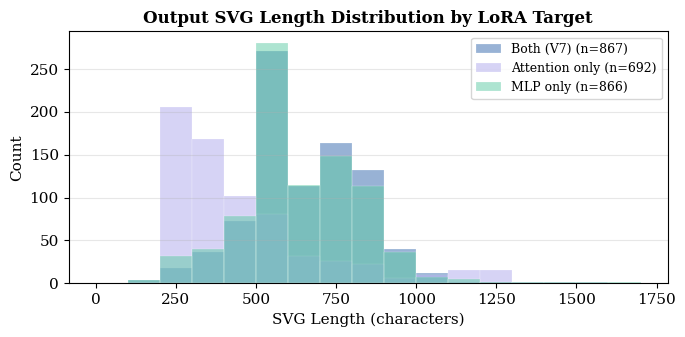

Saved: figures/output_length_dist.{png,pdf}


In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))

colors_hist = {'Both (V7)': '#3266ad', 'Attention only': '#AFA9EC', 'MLP only': '#5DCAA5'}

bins = np.arange(0, 1800, 100)
for label, stats in ablation_stats.items():
    ax.hist(stats['lengths'], bins=bins, alpha=0.5, color=colors_hist[label],
            label=f'{label} (n={stats["valid"]})', edgecolor='white', linewidth=0.3)

ax.set_xlabel('SVG Length (characters)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Output SVG Length Distribution by LoRA Target', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/output_length_dist.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/output_length_dist.pdf', bbox_inches='tight')
plt.show()
print('Saved: figures/output_length_dist.{png,pdf}')

## 8. Summary Statistics for Report

In [12]:
print('=' * 70)
print('SUMMARY STATISTICS FOR REPORT')
print('=' * 70)

print(f'\n--- Training Data ---')
print(f'Raw samples: 50,000')
print(f'After compression + filtering: 49,362 (98.7%)')
print(f'Mean original length: {np.mean(original_lens):.0f} chars')
print(f'Mean compressed length: {np.mean(compressed_lens):.0f} chars')
print(f'Compression ratio: {100*(1 - np.mean(compressed_lens)/np.mean(original_lens)):.0f}%')
print(f'Filtered outliers: {len(filtered_lens)} ({100*len(filtered_lens)/len(original_lens):.1f}%)')

print(f'\n--- Score Progression ---')
for v, s in zip(versions, scores):
    print(f'  {v}: {s}')

print(f'\n--- Ablation Results ---')
for label, stats in ablation_stats.items():
    cr = 100*stats['color_match']/max(stats['color_total'],1)
    mp = np.mean(stats['path_counts'])
    ml = np.mean(stats['lengths'])
    top_vb = stats['viewboxes'].most_common(1)[0] if stats['viewboxes'] else ('none', 0)
    print(f'  {label}:')
    print(f'    Valid={stats["valid"]}, Fallback={stats["fallback"]}')
    print(f'    Color match={cr:.1f}%, Mean paths={mp:.1f}, Mean len={ml:.0f}')
    print(f'    Top viewBox: {top_vb[0]} ({top_vb[1]} occurrences)')
    print(f'    Unique starts: {len(stats["unique_starts"])}')

print(f'\n--- Key Findings ---')
print(f'  MLP-only nearly matches full model (866 vs 867 valid, 59.8% vs 59.5% color)')
print(f'  Attention-only drastically different (692 valid, 30.6% color, 32x32 viewBox)')
print(f'  Data compression was the biggest single improvement (+3 points)')
print(f'  Adapter key mismatch invalidated 3 submission versions')

SUMMARY STATISTICS FOR REPORT

--- Training Data ---
Raw samples: 50,000
After compression + filtering: 49,362 (98.7%)
Mean original length: 2524 chars
Mean compressed length: 1076 chars
Compression ratio: 57%
Filtered outliers: 638 (1.3%)

--- Score Progression ---
  V1: 11.23
  V2: 11.83
  V3*: 10.96
  V4*: 11.07
  V5*: 10.21
  V7: 14.2
  V8: 14.35

--- Ablation Results ---
  Both (V7):
    Valid=867, Fallback=133
    Color match=59.5%, Mean paths=2.2, Mean len=648
    Top viewBox: 0.0 0.0 200.0 200.0 (800 occurrences)
    Unique starts: 9
  Attention only:
    Valid=692, Fallback=308
    Color match=30.6%, Mean paths=4.1, Mean len=465
    Top viewBox: 0 0 32 32 (432 occurrences)
    Unique starts: 9
  MLP only:
    Valid=866, Fallback=134
    Color match=59.8%, Mean paths=2.2, Mean len=635
    Top viewBox: 0.0 0.0 200.0 200.0 (795 occurrences)
    Unique starts: 8

--- Key Findings ---
  MLP-only nearly matches full model (866 vs 867 valid, 59.8% vs 59.5% color)
  Attention-only dra

In [13]:
print('\n\nAll figures saved to figures/ directory:')
for f in sorted(os.listdir('figures')):
    print(f'  figures/{f}')



All figures saved to figures/ directory:
  figures/ablation_comparison.pdf
  figures/ablation_comparison.png
  figures/ablation_viewbox.pdf
  figures/ablation_viewbox.png
  figures/compression_analysis.pdf
  figures/compression_analysis.png
  figures/loss_curves.pdf
  figures/loss_curves.png
  figures/output_length_dist.pdf
  figures/output_length_dist.png
  figures/score_progression.pdf
  figures/score_progression.png
